# Develop a meta learning model using machine learning and minimal data

Dataset: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset

Required libraries

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# Set up TensorFlow to use the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
tf.config.experimental.set_memory_growth(gpus[0], True)

Download Dataset from the kaggle link

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip breast-ultrasound-images-dataset.zip

 95% 185M/195M [00:02<00:00, 102MB/s] 
100% 195M/195M [00:02<00:00, 96.7MB/s]
Archive:  breast-ultrasound-images-dataset.zip
  inflating: Dataset_BUSI_with_GT/benign/benign (1).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (1)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask_1.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (103).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (103)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (104).png  
  in

Define the data directories

In [ ]:
# Define dataset directories
dataset_dir = '/content/Dataset_BUSI_with_GT'

# Create train, test, and validation directories
train_dir = os.path.join(dataset_dir, 'train')
test_dir = os.path.join(dataset_dir, 'test')
val_dir = os.path.join(dataset_dir, 'val')

# Create class directories in train, test, and validation directories
for folder in ['benign', 'malignant', 'normal']:
    os.makedirs(os.path.join(train_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(test_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(val_dir, folder), exist_ok=True)

# Move images to train, test, and validation directories
for folder in ['benign', 'malignant', 'normal']:
    images = os.listdir(os.path.join(dataset_dir, folder))
    train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)
    test_images, val_images = train_test_split(test_images, test_size=0.5, random_state=42)

    for img in train_images:
        if not img.endswith('_mask.png'):  # Exclude mask images
            # Check if there's a corresponding mask file
            shutil.move(os.path.join(dataset_dir, folder, img), os.path.join(train_dir, folder, img))

    for img in test_images:
        if not img.endswith('_mask.png'):  # Exclude mask images
            shutil.move(os.path.join(dataset_dir, folder, img), os.path.join(test_dir, folder, img))

    for img in val_images:
        if not img.endswith('_mask.png'):  # Exclude mask images
            shutil.move(os.path.join(dataset_dir, folder, img), os.path.join(val_dir, folder, img))



insight the image parameters and batch size

In [ ]:
img_width, img_height = 500, 500
batch_size = 32

Define data generators

In [ ]:
# Define data generators
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    '/content/Dataset_BUSI_with_GT/train',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical')

validation_generator = datagen.flow_from_directory(
    '/content/Dataset_BUSI_with_GT/val',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical')

test_generator = datagen.flow_from_directory(
    '/content/Dataset_BUSI_with_GT/test',
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical')

Found 1194 images belonging to 3 classes.
Found 199 images belonging to 3 classes.
Found 185 images belonging to 3 classes.


Showing the data with class name

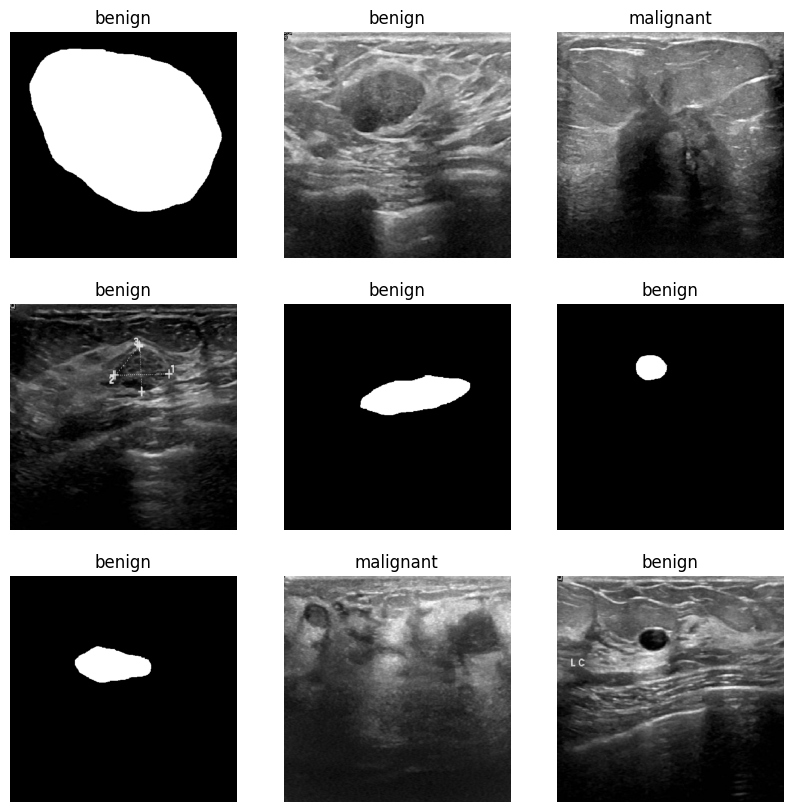

In [ ]:
# Show Sample Images from train_generator
sample_images, sample_labels = next(train_generator)
plt.figure(figsize=(10, 10))
class_indices = list(train_generator.class_indices.keys())  # Convert dict_keys to list
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(class_indices[np.argmax(sample_labels[i])])  # Access elements using list index
    plt.axis('off')
plt.show()

Designing a meta learning model, with minimal data

In [ ]:
# Defining the meta learning model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

fit the model with train dataset

In [ ]:
# Train the model
history= model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=20)

Epoch 1/20
27/27 [==============================] - 27s 615ms/step - loss: 1.2243 - accuracy: 0.5304 - val_loss: 0.8555 - val_accuracy: 0.6719
Epoch 2/20
27/27 [==============================] - 14s 499ms/step - loss: 0.5477 - accuracy: 0.7869 - val_loss: 0.9755 - val_accuracy: 0.6641
Epoch 3/20
27/27 [==============================] - 12s 435ms/step - loss: 0.3479 - accuracy: 0.8501 - val_loss: 1.0225 - val_accuracy: 0.7266
Epoch 4/20
27/27 [==============================] - 13s 470ms/step - loss: 0.2630 - accuracy: 0.8993 - val_loss: 1.1798 - val_accuracy: 0.6562
Epoch 5/20
27/27 [==============================] - 12s 432ms/step - loss: 0.1883 - accuracy: 0.9239 - val_loss: 2.0644 - val_accuracy: 0.7578
Epoch 6/20
27/27 [==============================] - 12s 436ms/step - loss: 0.1264 - accuracy: 0.9567 - val_loss: 1.9663 - val_accuracy: 0.6797
Epoch 7/20
27/27 [==============================] - 12s 432ms/step - loss: 0.0472 - accuracy: 0.9930 - val_loss: 1.9845 - val_accuracy: 0.7188

KeyboardInterrupt: 

plot the train accuracy rate

In [ ]:
# Plot Training Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Test with test images

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print('Test accuracy:', test_acc)


take test images and predict

In [ ]:
import matplotlib.pyplot as plt

# Define the test directory
test_dir = '/content/Dataset_BUSI_with_GT/test'

# Define the classes
classes = ['benign', 'malignant', 'normal']

# Iterate over the classes and perform testing
for class_name in classes:
    print(f'Testing for class: {class_name}')

    # Load test images for the current class
    test_images = os.listdir(os.path.join(test_dir, class_name))

    # Select a random image for testing
    random_image = np.random.choice(test_images)
    image_path = os.path.join(test_dir, class_name, random_image)

    # Load the image and preprocess it
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(img_width, img_height))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize the image

    # Predict the class probabilities
    probabilities = model.predict(img_array)[0]

    # Threshold the probabilities to generate the mask
    threshold = 0.5  # Adjust this threshold as needed
    mask = (probabilities > threshold).astype(np.uint8)

    # Display the original image
    plt.imshow(img)
    plt.title(f'Original Image ({class_name})')
    plt.axis('off')
    plt.show()



    # Print the prediction
    if probabilities[0] > probabilities[1]:
        print('Prediction: Benign')
    else:
        print('Prediction: Malignant')

    print('\n')
